# **Oil Price Time Series Analysis: ARMA and LSTM Modelling & Forecasting**

**Module:** Advanced Research Topics in Data Science  
**Author:** Sai Vara-Prasad Lekkalapudi  
**Date:** March 2026  

---

This notebook presents a comprehensive time series analysis of daily oil prices from September 2024 to February 2026. The analysis is structured in two parts:

- **Part 1:** Traditional ARMA/ARIMA modelling with stationarity testing, model selection via AIC, residual diagnostics, and 24-month forecasting.
- **Part 2:** An alternative LSTM (Long Short-Term Memory) deep learning approach for modelling and forecasting the same data.

Both models are compared on evaluation metrics and forecast quality.

## **1. Setup and Library Imports**

In [1]:
# ============================================================
# Section 1: Import all required libraries
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical tests
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA modelling
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Deep Learning - LSTM
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scipy for residual normality test
from scipy import stats

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('All libraries imported successfully.')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully.
TensorFlow version: 2.19.0


## **2. Data Loading and Preprocessing**

In [2]:
# ============================================================
# Section 2: Load and preprocess the oil price dataset
# ============================================================

# Load the CSV data
df = pd.read_csv('oil_prices_2426.csv')

# Rename columns for convenience
df.columns = ['date', 'price']

# Convert date column to datetime format (day/month/year)
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

# Set date as the index for time series operations
df.set_index('date', inplace=True)

# Sort by date to ensure chronological order
df.sort_index(inplace=True)

# Check for missing values
print('=== Dataset Overview ===')
print(f'Shape: {df.shape}')
print(f'Date Range: {df.index.min()} to {df.index.max()}')
print(f'Total Days: {len(df)}')
print(f'Missing Values: {df.isnull().sum().values[0]}')
print(f'\n=== Summary Statistics ===')
print(df.describe().round(2))

=== Dataset Overview ===
Shape: (500, 1)
Date Range: 2024-09-21 00:00:00 to 2026-02-02 00:00:00
Total Days: 500
Missing Values: 0

=== Summary Statistics ===
        price
count  500.00
mean    75.87
std     42.91
min     16.48
25%     35.37
50%     64.29
75%    111.57
max    158.78


---
# **PART 1: ARMA / ARIMA MODELLING**
---

## **3. Exploratory Data Analysis (EDA)**

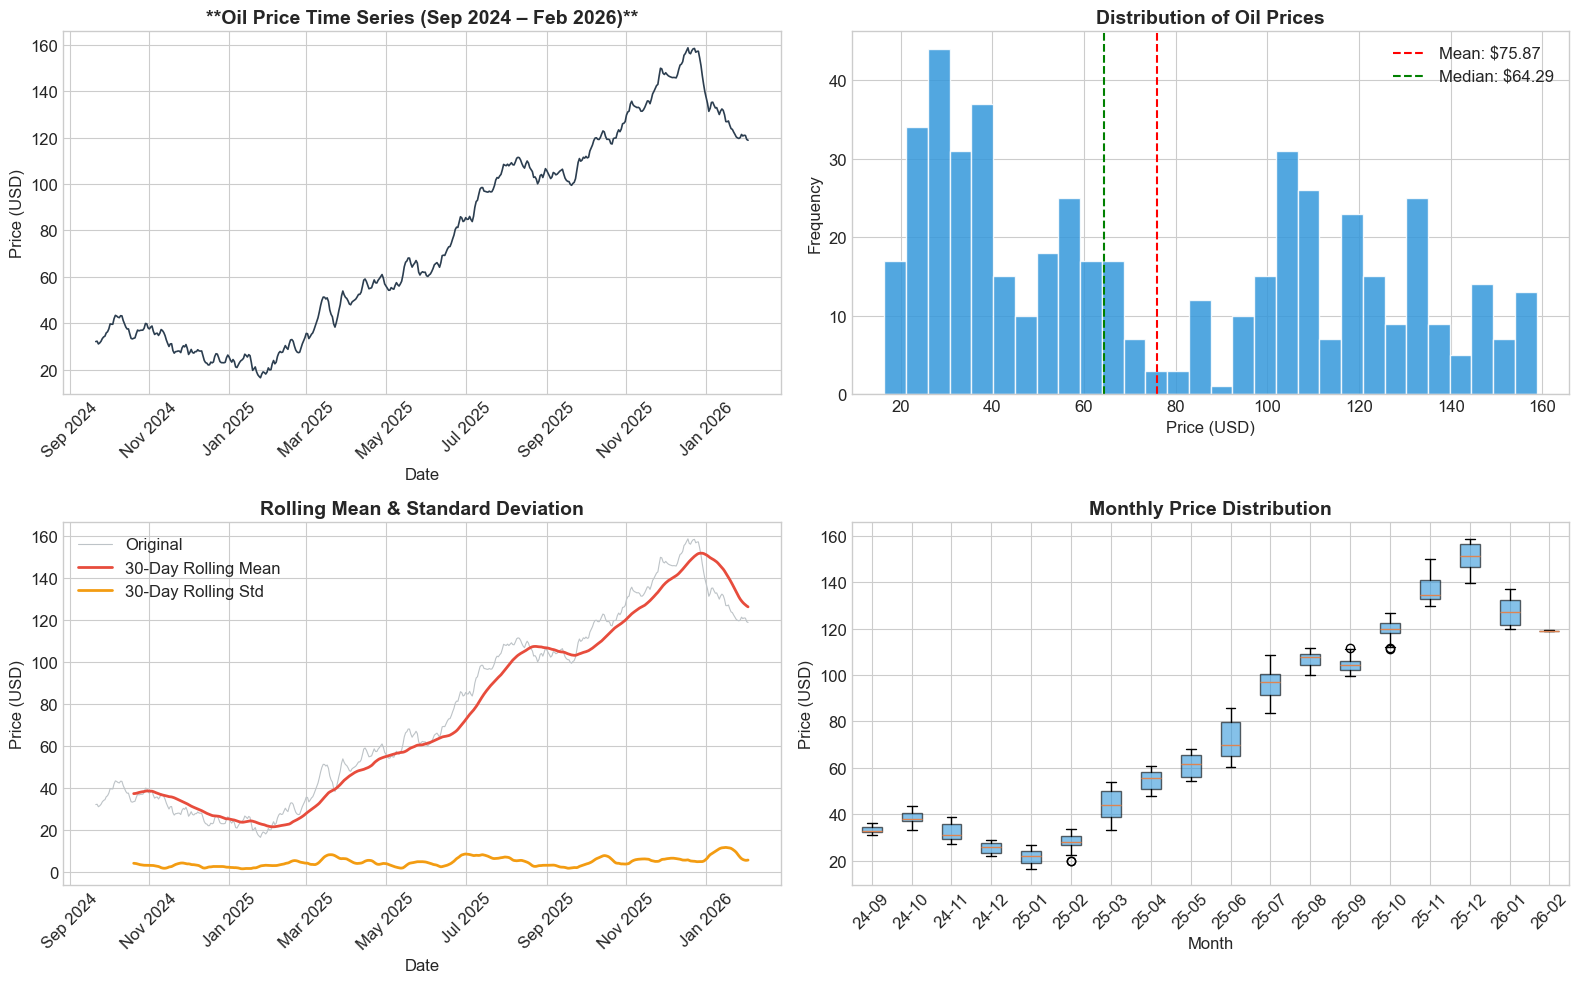

Figure 1: EDA overview saved.


In [3]:
# ============================================================
# Section 3: Initial visualisation of the oil price time series
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Raw time series
axes[0, 0].plot(df.index, df['price'], color='#2c3e50', linewidth=1.2)
axes[0, 0].set_title('**Oil Price Time Series (Sep 2024 – Feb 2026)**', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Distribution of prices
axes[0, 1].hist(df['price'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["price"].mean():.2f}')
axes[0, 1].axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: ${df["price"].median():.2f}')
axes[0, 1].set_title('Distribution of Oil Prices', fontweight='bold')
axes[0, 1].set_xlabel('Price (USD)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Plot 3: Rolling mean and standard deviation (30-day window)
rolling_mean = df['price'].rolling(window=30).mean()
rolling_std = df['price'].rolling(window=30).std()
axes[1, 0].plot(df.index, df['price'], color='#bdc3c7', linewidth=0.8, label='Original')
axes[1, 0].plot(rolling_mean.index, rolling_mean, color='#e74c3c', linewidth=2, label='30-Day Rolling Mean')
axes[1, 0].plot(rolling_std.index, rolling_std, color='#f39c12', linewidth=2, label='30-Day Rolling Std')
axes[1, 0].set_title('Rolling Mean & Standard Deviation', fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price (USD)')
axes[1, 0].legend()
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Box plot by month
df_monthly = df.copy()
df_monthly['month'] = df_monthly.index.to_period('M').astype(str)
monthly_groups = df_monthly.groupby('month')['price'].apply(list)
box_data = [monthly_groups[m] for m in monthly_groups.index]
axes[1, 1].boxplot(box_data, labels=[m[-5:] for m in monthly_groups.index], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1, 1].set_title('Monthly Price Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Price (USD)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1: EDA overview saved.')

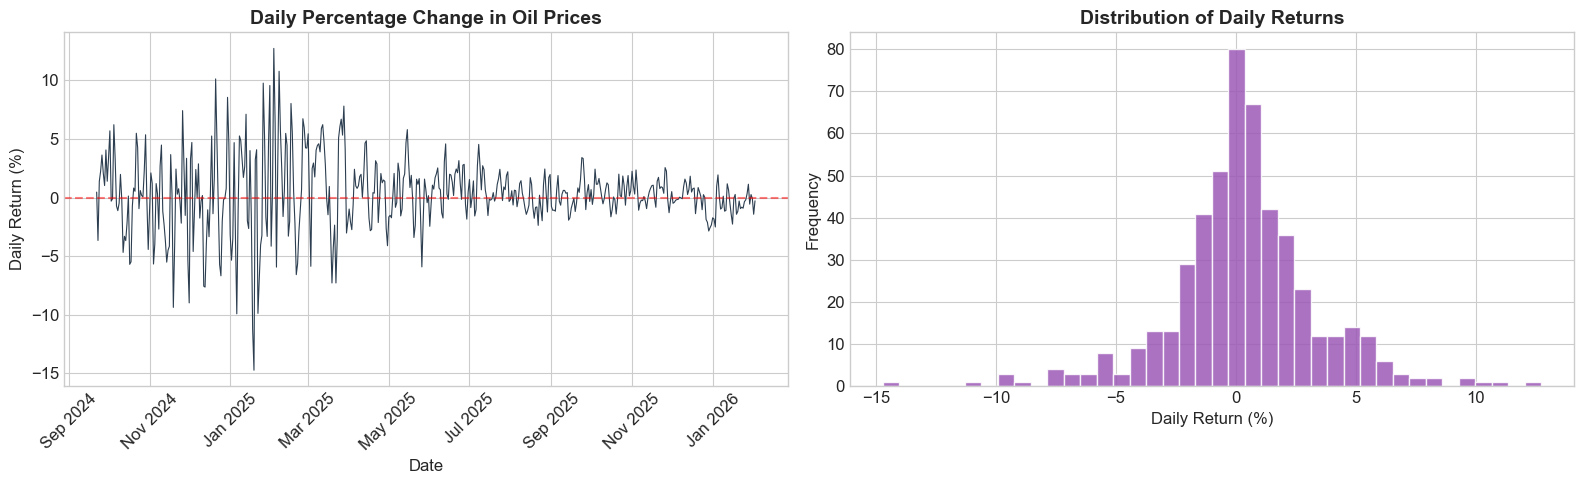

In [4]:
# ============================================================
# Additional EDA: Daily returns / percentage change
# ============================================================

df['returns'] = df['price'].pct_change() * 100  # percentage daily change

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df.index, df['returns'], color='#2c3e50', linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Daily Percentage Change in Oil Prices', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Return (%)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df['returns'].dropna(), bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Daily Returns', fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig2_returns_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## **4. Stationarity Testing**

A stationary time series has constant mean, variance, and autocovariance over time. ARMA models require stationary data. We apply the following tests:

- **Augmented Dickey-Fuller (ADF) Test:** Null hypothesis = series has a unit root (non-stationary).
- **KPSS Test:** Null hypothesis = series is stationary.
- **ACF and PACF Plots:** Visual inspection for autocorrelation decay patterns.

In [5]:
# ============================================================
# Section 4: Stationarity tests - ADF and KPSS
# ============================================================

def adf_test(series, title=''):
    """Perform Augmented Dickey-Fuller test and print results."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n=== ADF Test: {title} ===')
    print(f'Test Statistic : {result[0]:.4f}')
    print(f'P-Value        : {result[1]:.6f}')
    print(f'Lags Used      : {result[2]}')
    print(f'Observations   : {result[3]}')
    for key, value in result[4].items():
        print(f'Critical Value ({key}): {value:.4f}')
    if result[1] <= 0.05:
        print('>> Result: STATIONARY (reject H0 at 5% significance)')
    else:
        print('>> Result: NON-STATIONARY (fail to reject H0)')
    return result[1]

def kpss_test(series, title=''):
    """Perform KPSS test and print results."""
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'\n=== KPSS Test: {title} ===')
    print(f'Test Statistic : {result[0]:.4f}')
    print(f'P-Value        : {result[1]:.6f}')
    print(f'Lags Used      : {result[2]}')
    for key, value in result[3].items():
        print(f'Critical Value ({key}): {value:.4f}')
    if result[1] <= 0.05:
        print('>> Result: NON-STATIONARY (reject H0 at 5% significance)')
    else:
        print('>> Result: STATIONARY (fail to reject H0)')
    return result[1]

# Test on original series
print('=' * 60)
print('STATIONARITY TESTS ON ORIGINAL SERIES')
print('=' * 60)
adf_p = adf_test(df['price'], 'Original Oil Price Series')
kpss_p = kpss_test(df['price'], 'Original Oil Price Series')

STATIONARITY TESTS ON ORIGINAL SERIES

=== ADF Test: Original Oil Price Series ===
Test Statistic : -0.5462
P-Value        : 0.882674
Lags Used      : 17
Observations   : 482
Critical Value (1%): -3.4440
Critical Value (5%): -2.8676
Critical Value (10%): -2.5700
>> Result: NON-STATIONARY (fail to reject H0)

=== KPSS Test: Original Oil Price Series ===
Test Statistic : 3.7056
P-Value        : 0.010000
Lags Used      : 12
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390
>> Result: NON-STATIONARY (reject H0 at 5% significance)


/var/folders/bn/b8308xfx04g235ttkq_q6vym0000gn/T/ipykernel_25526/552921187.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


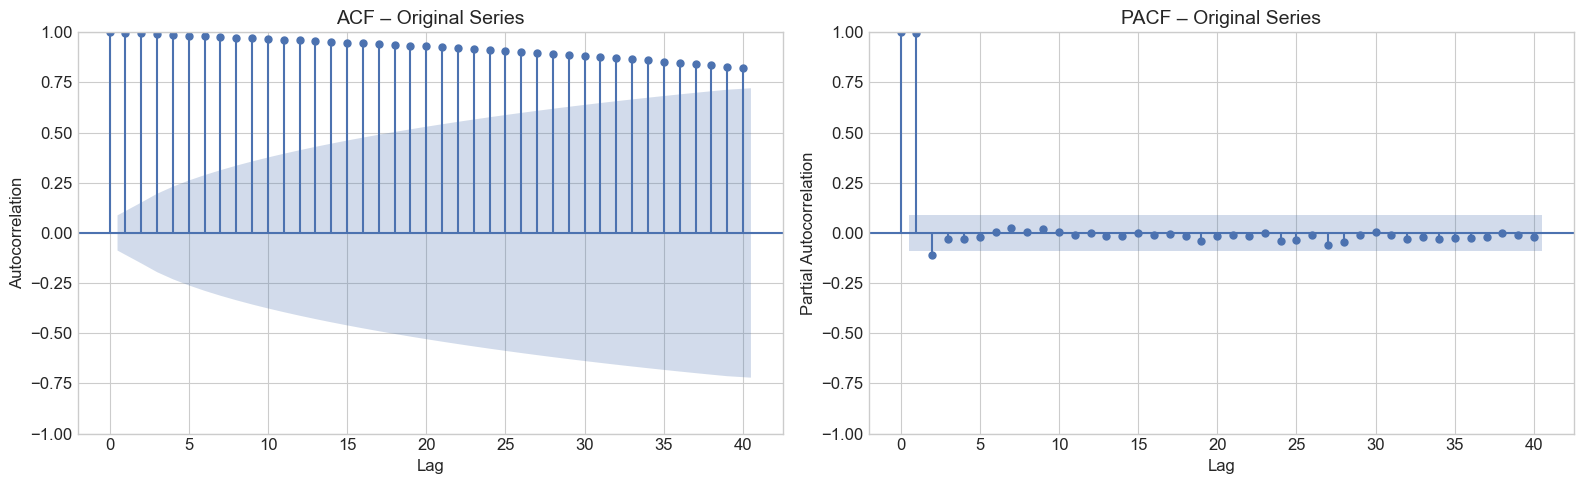

The slow decay in the ACF confirms the series is non-stationary.


In [6]:
# ============================================================
# Section 4b: ACF and PACF plots on the original series
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['price'].dropna(), lags=40, ax=axes[0], title='ACF – Original Series')
plot_pacf(df['price'].dropna(), lags=40, ax=axes[1], title='PACF – Original Series', method='ywm')

axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.savefig('fig3_acf_pacf_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('The slow decay in the ACF confirms the series is non-stationary.')

## **5. Differencing to Achieve Stationarity**

STATIONARITY TESTS ON FIRST-ORDER DIFFERENCED SERIES

=== ADF Test: First-Order Differenced ===
Test Statistic : -4.5415
P-Value        : 0.000165
Lags Used      : 16
Observations   : 482
Critical Value (1%): -3.4440
Critical Value (5%): -2.8676
Critical Value (10%): -2.5700
>> Result: STATIONARY (reject H0 at 5% significance)

=== KPSS Test: First-Order Differenced ===
Test Statistic : 0.1903
P-Value        : 0.100000
Lags Used      : 8
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390
>> Result: STATIONARY (fail to reject H0)


/var/folders/bn/b8308xfx04g235ttkq_q6vym0000gn/T/ipykernel_25526/552921187.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


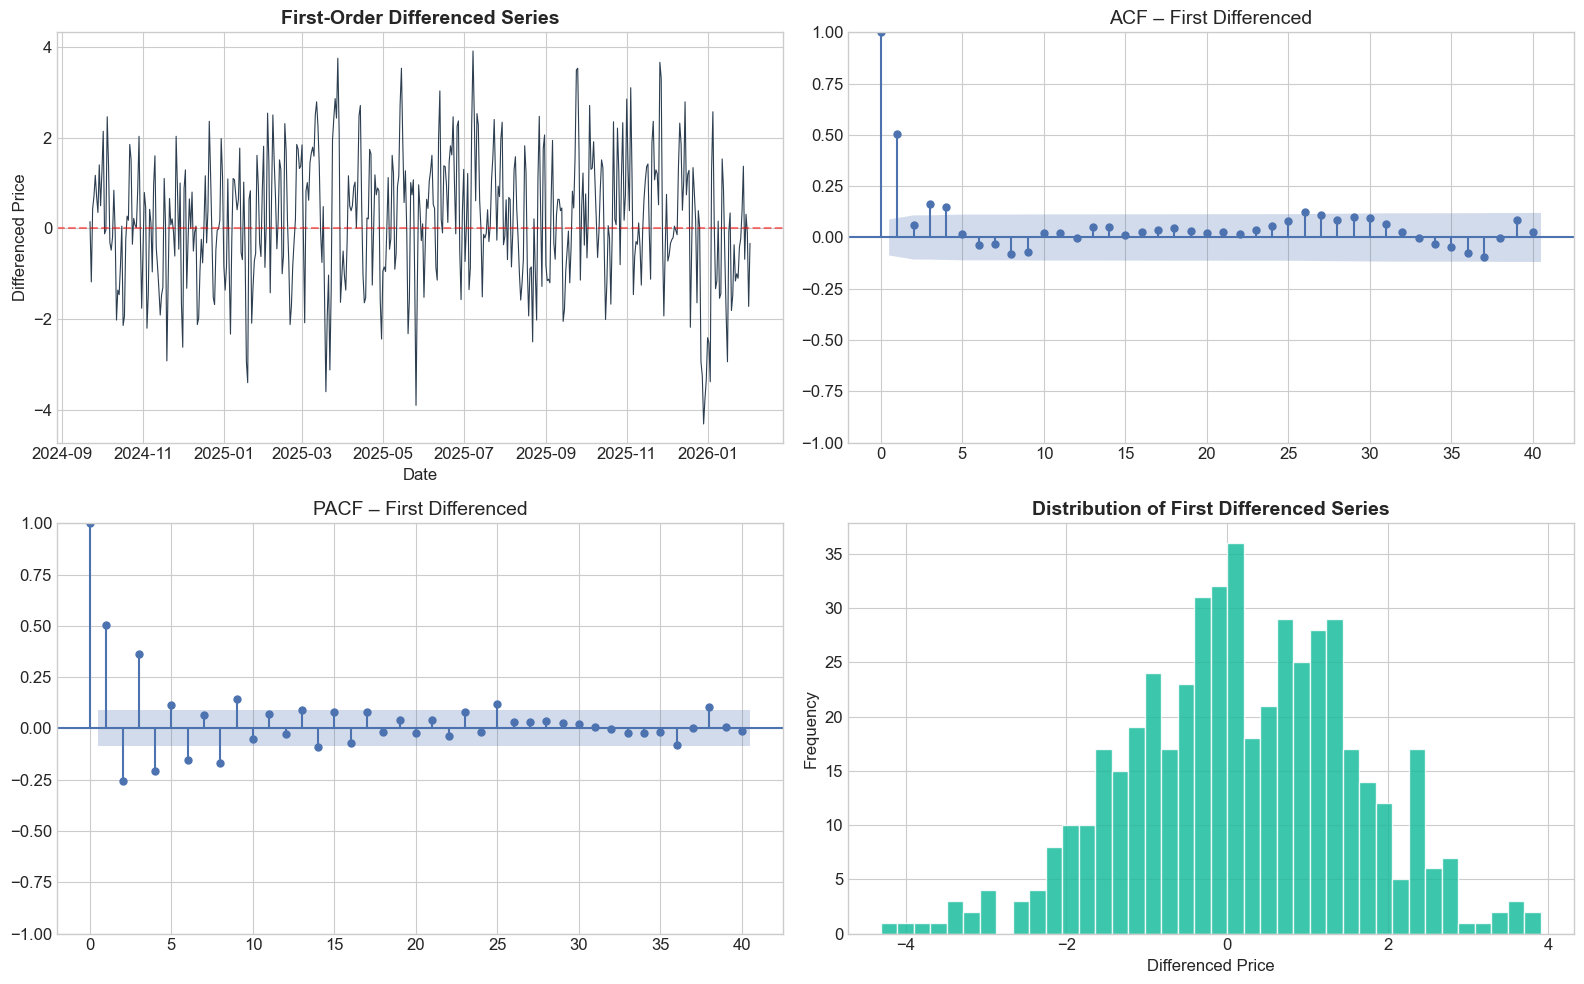

First-order differencing achieves stationarity. d=1 is appropriate.


In [7]:
# ============================================================
# Section 5: Apply first-order differencing and re-test
# ============================================================

# First-order differencing
df['price_diff1'] = df['price'].diff()

# Second-order differencing (for comparison)
df['price_diff2'] = df['price'].diff().diff()

# Test first-order differenced series
print('=' * 60)
print('STATIONARITY TESTS ON FIRST-ORDER DIFFERENCED SERIES')
print('=' * 60)
adf_p_d1 = adf_test(df['price_diff1'], 'First-Order Differenced')
kpss_p_d1 = kpss_test(df['price_diff1'], 'First-Order Differenced')

# Visualise differenced series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# First-order differenced series
axes[0, 0].plot(df.index, df['price_diff1'], color='#2c3e50', linewidth=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('First-Order Differenced Series', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Differenced Price')

# ACF of differenced series
plot_acf(df['price_diff1'].dropna(), lags=40, ax=axes[0, 1], title='ACF – First Differenced')

# PACF of differenced series
plot_pacf(df['price_diff1'].dropna(), lags=40, ax=axes[1, 0], title='PACF – First Differenced', method='ywm')

# Distribution of differenced series
axes[1, 1].hist(df['price_diff1'].dropna(), bins=40, color='#1abc9c', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Distribution of First Differenced Series', fontweight='bold')
axes[1, 1].set_xlabel('Differenced Price')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig4_differenced_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('First-order differencing achieves stationarity. d=1 is appropriate.')

## **6. ARIMA Model Selection via AIC Grid Search**

We perform an exhaustive grid search over all combinations of:
- **p** (AR order): 0 to 8  
- **d** (differencing order): 0 to 2  
- **q** (MA order): 0 to 8  

The model with the **lowest AIC (Akaike Information Criterion)** is selected as the optimal model.

In [8]:
# ============================================================
# Section 6: Grid search for optimal ARIMA(p,d,q) parameters
# ============================================================

def arima_grid_search(data, p_range, d_range, q_range):
    """
    Perform an exhaustive grid search over ARIMA(p,d,q) combinations.
    
    Parameters:
    -----------
    data : pd.Series - the time series to model
    p_range : range - AR order range
    d_range : range - differencing order range
    q_range : range - MA order range
    
    Returns:
    --------
    results_df : pd.DataFrame - sorted results with AIC scores
    best_order : tuple - (p, d, q) of the best model
    """
    results = []
    total = len(p_range) * len(d_range) * len(q_range)
    count = 0
    
    for p, d, q in product(p_range, d_range, q_range):
        count += 1
        if count % 50 == 0:
            print(f'  Progress: {count}/{total} combinations tested...')
        try:
            model = ARIMA(data, order=(p, d, q))
            fitted = model.fit()
            results.append({
                'p': p, 'd': d, 'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'Log_Likelihood': fitted.llf
            })
        except:
            continue
    
    results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    best_order = (int(results_df.iloc[0]['p']), 
                  int(results_df.iloc[0]['d']), 
                  int(results_df.iloc[0]['q']))
    return results_df, best_order

# Define parameter ranges as specified in the assignment
p_range = range(0, 9)   # p = [0, 8]
d_range = range(0, 3)   # d = [0, 2]
q_range = range(0, 9)   # q = [0, 8]

print('Starting ARIMA grid search (p=0-8, d=0-2, q=0-8)...')
print(f'Total combinations: {len(p_range) * len(d_range) * len(q_range)}')
print('-' * 50)

results_df, best_order = arima_grid_search(df['price'], p_range, d_range, q_range)

print(f'\n=== Grid Search Complete ===')
print(f'Best Model: ARIMA{best_order}')
print(f'Best AIC: {results_df.iloc[0]["AIC"]:.2f}')
print(f'\nTop 10 Models by AIC:')
print(results_df.head(10).to_string(index=False))

Starting ARIMA grid search (p=0-8, d=0-2, q=0-8)...
Total combinations: 243
--------------------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

  Progress: 50/243 combinations tested...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

  Progress: 100/243 combinations tested...


...

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle

  Progress: 200/243 combinations tested...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequenc


=== Grid Search Complete ===
Best Model: ARIMA(2, 2, 7)
Best AIC: 1429.22

Top 10 Models by AIC:
 p  d  q         AIC         BIC  Log_Likelihood
 2  2  7 1429.216571 1471.322572     -704.608286
 4  1  5 1429.771989 1471.898050     -704.885994
 0  1  5 1429.897917 1455.173554     -708.948958
 1  1  4 1430.457760 1455.733397     -709.228880
 4  1  8 1430.507906 1485.271786     -702.253953
 2  1  4 1430.851612 1460.339854     -708.425806
 5  1  5 1430.983812 1477.322479     -704.491906
 4  1  1 1431.110534 1456.386170     -709.555267
 0  1  6 1431.355376 1460.843618     -708.677688
 3  1  3 1431.692968 1461.181210     -708.846484


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## **7. Fit the Best ARIMA Model**

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Fitting ARIMA(2, 2, 7) model...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.608
Date:                Tue, 10 Mar 2026   AIC                           1429.217
Time:                        21:03:41   BIC                           1471.323
Sample:                    09-21-2024   HQIC                          1445.742
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1800      0.032    -37.396      0.000      -1.242      -1.118
ar.L2         -0.9181      0.032    -28.763      0.000      -0.981      -0.856
ma.L1          1.1517      0.359      3.205      0.0

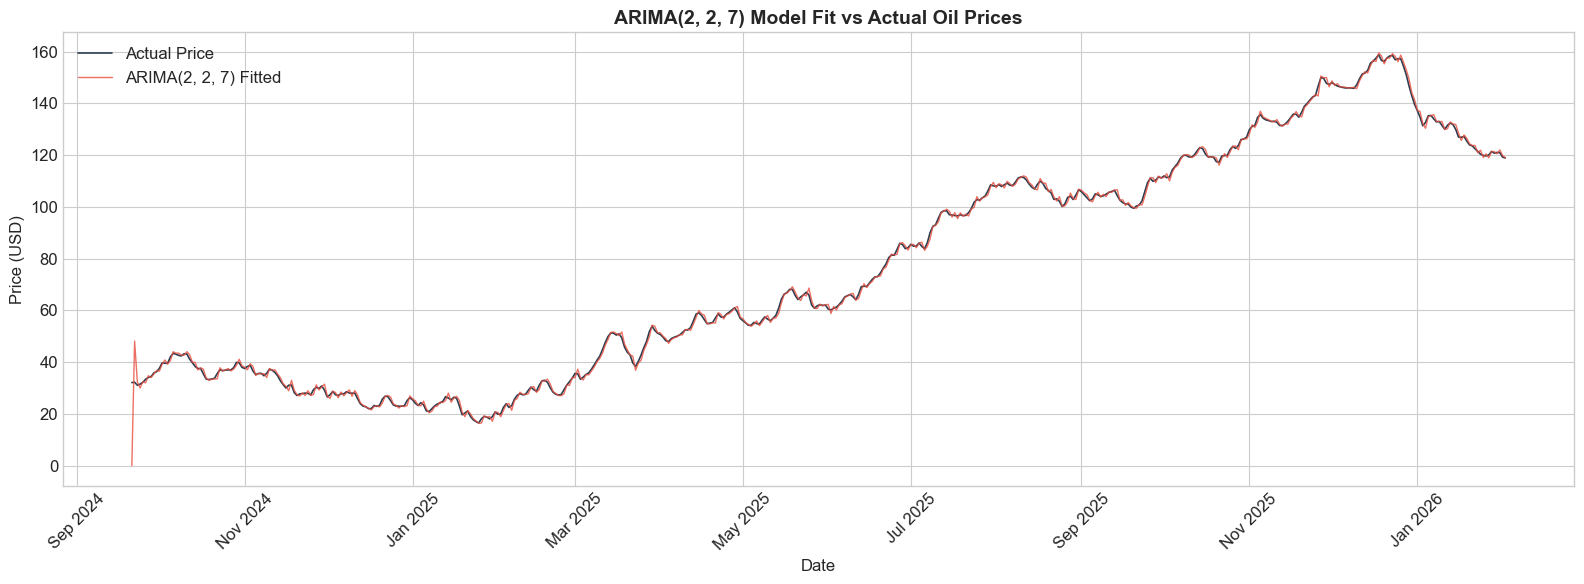

In [9]:
# ============================================================
# Section 7: Fit the optimal ARIMA model and display summary
# ============================================================

print(f'Fitting ARIMA{best_order} model...')
best_model = ARIMA(df['price'], order=best_order)
best_fit = best_model.fit()

print(best_fit.summary())

# Plot fitted values vs actual data
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['price'], label='Actual Price', color='#2c3e50', linewidth=1.2)
ax.plot(df.index, best_fit.fittedvalues, label=f'ARIMA{best_order} Fitted', 
        color='#e74c3c', linewidth=1.0, alpha=0.8)
ax.set_title(f'ARIMA{best_order} Model Fit vs Actual Oil Prices', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig5_arima_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## **8. Residual Diagnostics**

Assessing model adequacy by examining whether the residuals behave as white noise.

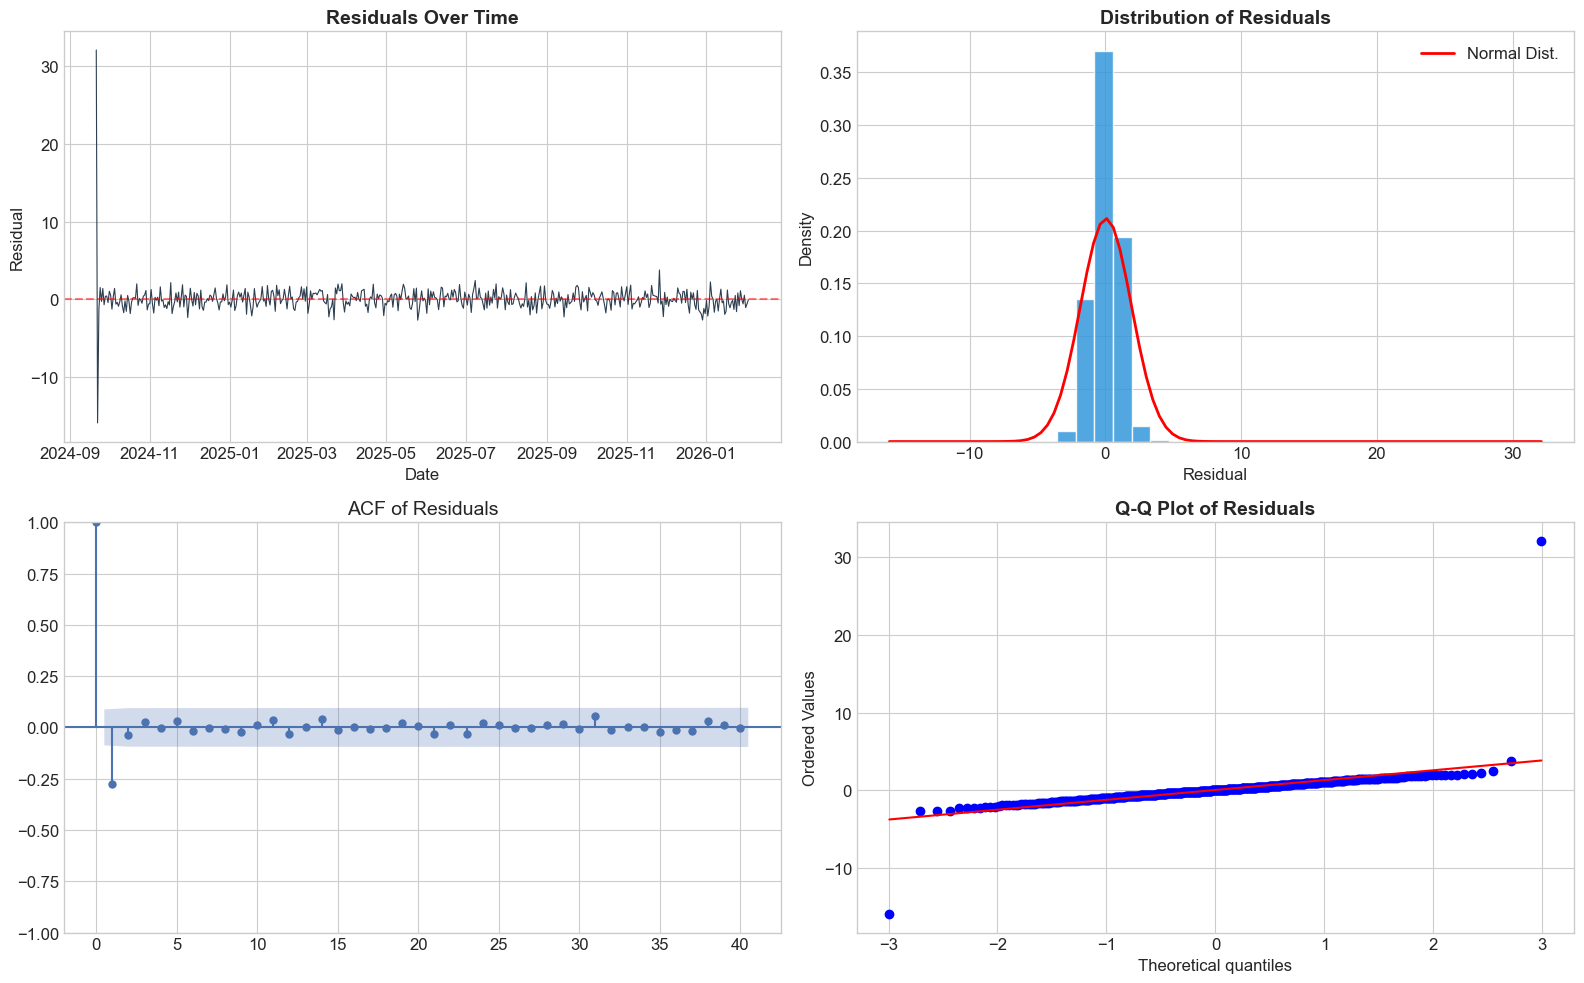


=== Ljung-Box Test on Residuals ===
      lb_stat  lb_pvalue
10  40.274994   0.000015
20  42.736249   0.002215
30  44.469285   0.043217

Shapiro-Wilk Test: statistic=0.4628, p-value=0.000000
>> Residuals deviate from normality (common in financial data).

Residual Mean: 0.0448
Residual Std:  1.8863


In [10]:
# ============================================================
# Section 8: Analyse model residuals for goodness of fit
# ============================================================

residuals = best_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuals over time
axes[0, 0].plot(residuals.index, residuals, color='#2c3e50', linewidth=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual')

# Histogram of residuals
axes[0, 1].hist(residuals, bins=35, color='#3498db', edgecolor='white', alpha=0.85, density=True)
# Overlay a normal distribution for comparison
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
                'r-', linewidth=2, label='Normal Dist.')
axes[0, 1].set_title('Distribution of Residuals', fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# ACF of residuals
plot_acf(residuals.dropna(), lags=40, ax=axes[1, 0], title='ACF of Residuals')

# QQ plot
stats.probplot(residuals.dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test for autocorrelation in residuals
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_results = acorr_ljungbox(residuals.dropna(), lags=[10, 20, 30], return_df=True)
print('\n=== Ljung-Box Test on Residuals ===')
print(lb_results)

# Shapiro-Wilk test for normality
sw_stat, sw_p = stats.shapiro(residuals.dropna()[:500])  # limit to 500 for Shapiro
print(f'\nShapiro-Wilk Test: statistic={sw_stat:.4f}, p-value={sw_p:.6f}')
if sw_p > 0.05:
    print('>> Residuals are approximately normally distributed.')
else:
    print('>> Residuals deviate from normality (common in financial data).')

print(f'\nResidual Mean: {residuals.mean():.4f}')
print(f'Residual Std:  {residuals.std():.4f}')

## **9. ARIMA Model Performance Evaluation**

Training set: 440 observations (2024-09-21 00:00:00 to 2025-12-04 00:00:00)
Test set: 60 observations (2025-12-05 00:00:00 to 2026-02-02 00:00:00)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== ARIMA(2, 2, 7) Evaluation Metrics ===
RMSE : 27.2517
MAE  : 21.3318
MAPE : 16.75%


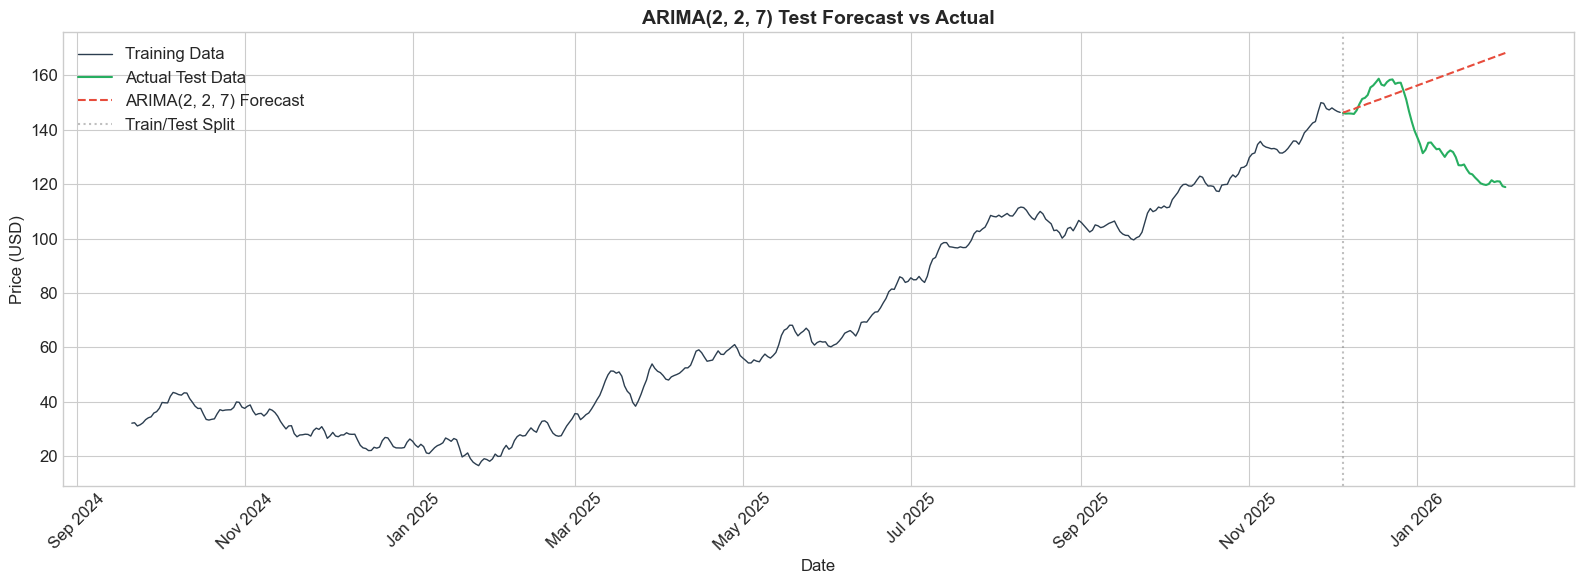

In [11]:
# ============================================================
# Section 9: Evaluate model performance using train-test split
# ============================================================

# Use last 60 days as test set (approx 2 months)
train_size = len(df) - 60
train = df['price'][:train_size]
test = df['price'][train_size:]

print(f'Training set: {len(train)} observations ({train.index.min()} to {train.index.max()})')
print(f'Test set: {len(test)} observations ({test.index.min()} to {test.index.max()})')

# Fit model on training data
model_train = ARIMA(train, order=best_order)
fit_train = model_train.fit()

# Forecast on test period
forecast_test = fit_train.forecast(steps=len(test))

# Compute evaluation metrics
def compute_metrics(actual, predicted, model_name=''):
    """Compute and display regression evaluation metrics."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    
    print(f'\n=== {model_name} Evaluation Metrics ===')
    print(f'RMSE : {rmse:.4f}')
    print(f'MAE  : {mae:.4f}')
    print(f'MAPE : {mape:.2f}%')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

arima_metrics = compute_metrics(test.values, forecast_test.values, f'ARIMA{best_order}')

# Plot prediction vs actual
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train.index, train, label='Training Data', color='#2c3e50', linewidth=1.0)
ax.plot(test.index, test, label='Actual Test Data', color='#27ae60', linewidth=1.5)
ax.plot(test.index, forecast_test, label=f'ARIMA{best_order} Forecast', 
        color='#e74c3c', linewidth=1.5, linestyle='--')
ax.axvline(test.index[0], color='grey', linestyle=':', alpha=0.5, label='Train/Test Split')
ax.set_title(f'ARIMA{best_order} Test Forecast vs Actual', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig7_arima_test_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## **10. ARIMA 24-Month Forecast with Confidence Intervals**

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


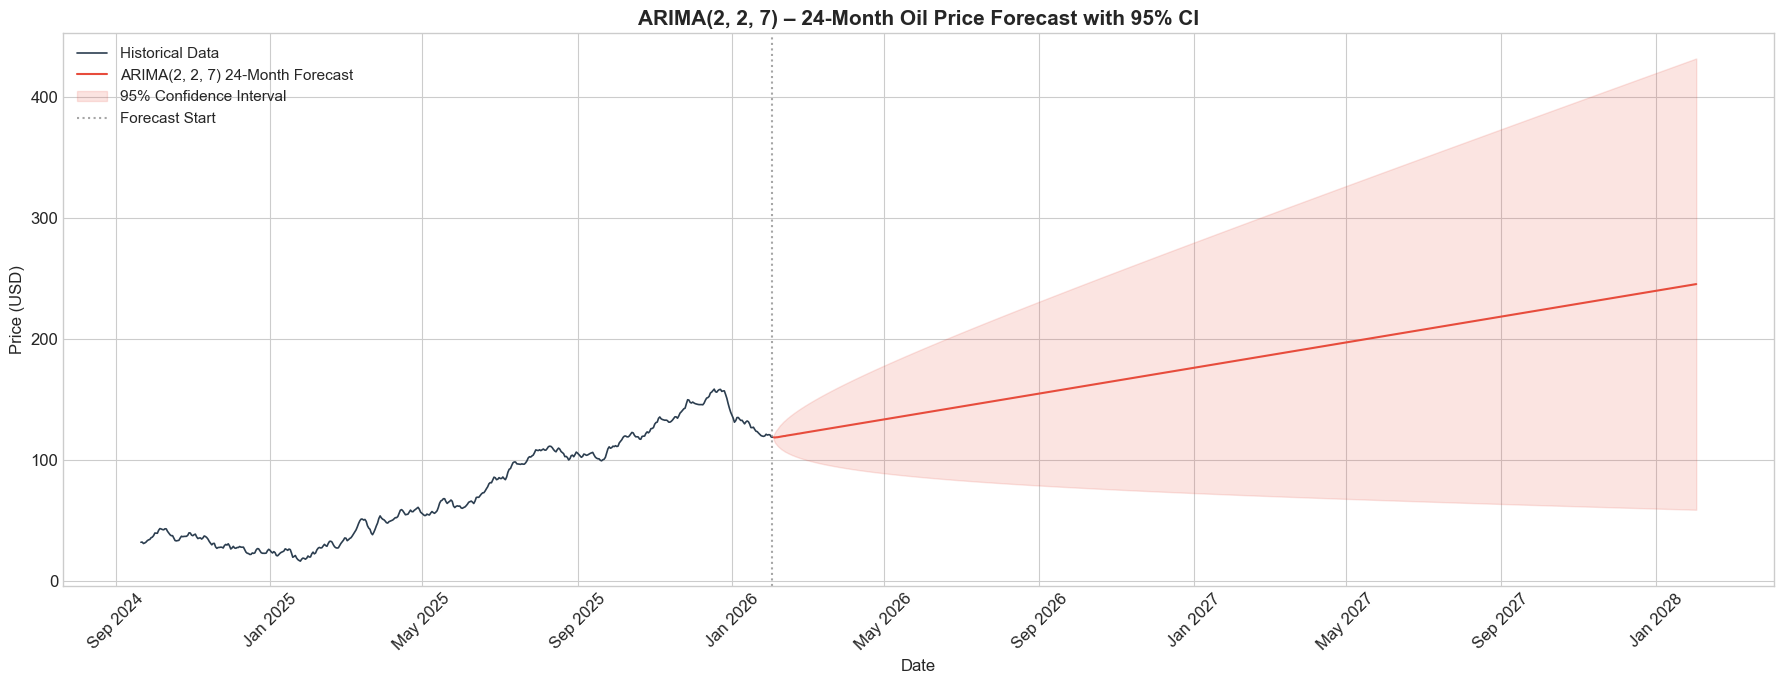


Forecast Period: 2026-02-03 to 2028-02-02
Forecast Start Price: $118.90
Forecast End Price: $245.63
95% CI at End: [$59.00, $432.26]


In [12]:
# ============================================================
# Section 10: Generate 24-month forecast with confidence bands
# ============================================================

# Refit on full dataset
final_arima = ARIMA(df['price'], order=best_order)
final_arima_fit = final_arima.fit()

# Forecast 24 months (approx 730 days)
forecast_steps = 730  # approximately 24 months of daily data
forecast_result = final_arima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

# Create forecast date index
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

# Plot full series with forecast
fig, ax = plt.subplots(figsize=(18, 7))

# Historical data
ax.plot(df.index, df['price'], label='Historical Data', color='#2c3e50', linewidth=1.2)

# Forecast
ax.plot(forecast_dates, forecast_mean, label=f'ARIMA{best_order} 24-Month Forecast',
        color='#e74c3c', linewidth=1.5)

# Confidence intervals
ax.fill_between(forecast_dates,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='#e74c3c', alpha=0.15, label='95% Confidence Interval')

ax.axvline(last_date, color='grey', linestyle=':', alpha=0.7, label='Forecast Start')
ax.set_title(f'ARIMA{best_order} – 24-Month Oil Price Forecast with 95% CI', fontweight='bold', fontsize=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig8_arima_24month_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nForecast Period: {forecast_dates[0].strftime("%Y-%m-%d")} to {forecast_dates[-1].strftime("%Y-%m-%d")}')
print(f'Forecast Start Price: ${forecast_mean.iloc[0]:.2f}')
print(f'Forecast End Price: ${forecast_mean.iloc[-1]:.2f}')
print(f'95% CI at End: [${forecast_ci.iloc[-1, 0]:.2f}, ${forecast_ci.iloc[-1, 1]:.2f}]')

---
# **PART 2: LSTM (Long Short-Term Memory) ALTERNATIVE MODEL**
---

LSTM networks are a specialised form of Recurrent Neural Network (RNN) designed to capture long-term dependencies in sequential data. Unlike ARIMA which assumes linear relationships, LSTMs can model complex non-linear patterns in time series through their gated memory architecture (Hochreiter and Schmidhuber, 1997).

## **11. Data Preparation for LSTM**

In [13]:
# ============================================================
# Section 11: Prepare data for LSTM model
# ============================================================

# Scale the data to [0, 1] range for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
price_scaled = scaler.fit_transform(df['price'].values.reshape(-1, 1))

def create_sequences(data, look_back=30):
    """
    Create input-output sequence pairs for LSTM training.
    
    Parameters:
    -----------
    data : np.array - scaled time series data
    look_back : int - number of past time steps to use as input features
    
    Returns:
    --------
    X : np.array - input sequences of shape (samples, look_back, 1)
    y : np.array - target values
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Define look-back window
LOOK_BACK = 30

# Create sequences
X, y = create_sequences(price_scaled, LOOK_BACK)

# Reshape X for LSTM: (samples, time_steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split (80-20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Look-back window: {LOOK_BACK} days')
print(f'Total sequences: {len(X)}')
print(f'Training set: {X_train.shape[0]} sequences')
print(f'Test set: {X_test.shape[0]} sequences')
print(f'Input shape: {X_train.shape}')

Look-back window: 30 days
Total sequences: 470
Training set: 376 sequences
Test set: 94 sequences
Input shape: (376, 30, 1)


## **12. LSTM Model Architecture and Hyperparameter Tuning**

In [14]:
# ============================================================
# Section 12: Build, compile, and train the LSTM model
# ============================================================

def build_lstm_model(look_back, units_1=128, units_2=64, dropout_rate=0.2):
    """
    Build a stacked LSTM model for time series prediction.
    
    Parameters:
    -----------
    look_back : int - input sequence length
    units_1 : int - neurons in first LSTM layer
    units_2 : int - neurons in second LSTM layer
    dropout_rate : float - dropout rate for regularisation
    
    Returns:
    --------
    model : keras Sequential model
    """
    model = Sequential([
        # First LSTM layer with return sequences for stacking
        LSTM(units=units_1, return_sequences=True, input_shape=(look_back, 1)),
        Dropout(dropout_rate),
        
        # Second LSTM layer
        LSTM(units=units_2, return_sequences=False),
        Dropout(dropout_rate),
        
        # Dense output layers
        Dense(32, activation='relu'),
        Dense(1)  # single output for price prediction
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mean_squared_error')
    return model

# Hyperparameter tuning: test different configurations
configs = [
    {'units_1': 64,  'units_2': 32,  'dropout': 0.2, 'batch': 32},
    {'units_1': 128, 'units_2': 64,  'dropout': 0.2, 'batch': 32},
    {'units_1': 128, 'units_2': 64,  'dropout': 0.3, 'batch': 16},
]

print('=== Hyperparameter Tuning ===')
best_val_loss = float('inf')
best_config = None

for i, cfg in enumerate(configs):
    print(f'\nConfig {i+1}: units=({cfg["units_1"]},{cfg["units_2"]}), '
          f'dropout={cfg["dropout"]}, batch_size={cfg["batch"]}')
    
    model = build_lstm_model(LOOK_BACK, cfg['units_1'], cfg['units_2'], cfg['dropout'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=cfg['batch'],
        validation_split=0.15,
        callbacks=[early_stop],
        verbose=0
    )
    
    val_loss = min(history.history['val_loss'])
    print(f'  Best Val Loss: {val_loss:.6f}')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = cfg
        best_model_lstm = model
        best_history = history

print(f'\n=== Best Configuration ===')
print(f'Units: ({best_config["units_1"]}, {best_config["units_2"]})')
print(f'Dropout: {best_config["dropout"]}')
print(f'Batch Size: {best_config["batch"]}')
print(f'Best Validation Loss: {best_val_loss:.6f}')

=== Hyperparameter Tuning ===

Config 1: units=(64,32), dropout=0.2, batch_size=32


2026-03-10 21:03:44.431691: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-10 21:03:44.432082: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-10 21:03:44.432085: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1773176624.432418 6645272 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773176624.432746 6645272 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-03-10 21:03:45.092074: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1773176625.097500 6645272 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: 

  Best Val Loss: 0.000908

Config 2: units=(128,64), dropout=0.2, batch_size=32
  Best Val Loss: 0.000605

Config 3: units=(128,64), dropout=0.3, batch_size=16
  Best Val Loss: 0.000791

=== Best Configuration ===
Units: (128, 64)
Dropout: 0.2
Batch Size: 32
Best Validation Loss: 0.000605


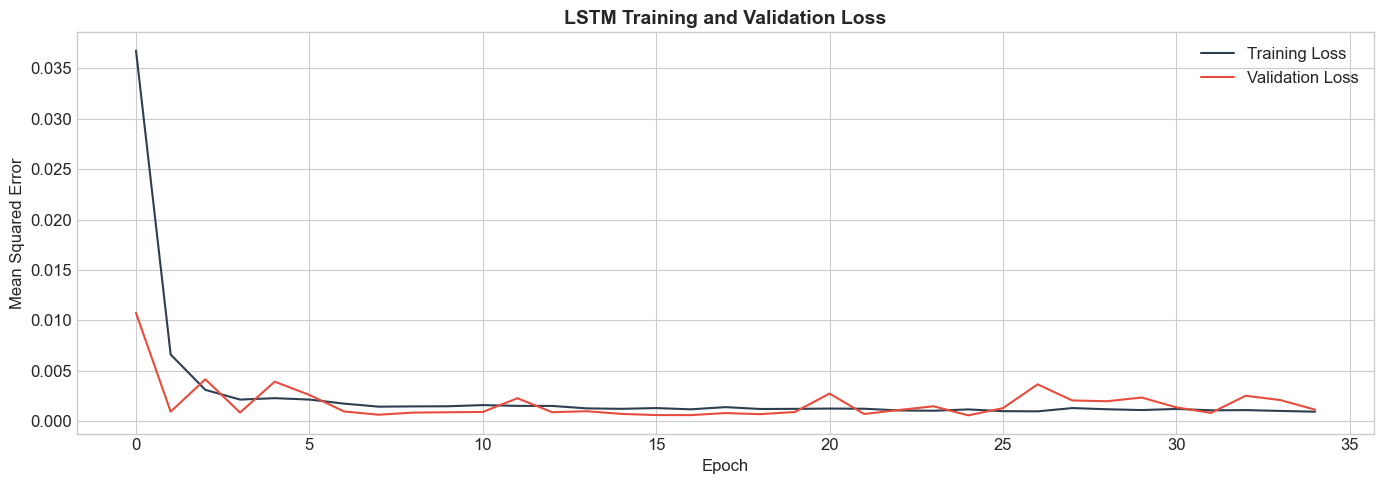

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,245 (1.35 MB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,164 (922.52 KB)

In [15]:
# ============================================================
# Section 12b: Plot training history
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(best_history.history['loss'], label='Training Loss', color='#2c3e50', linewidth=1.5)
ax.plot(best_history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=1.5)
ax.set_title('LSTM Training and Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Model summary
best_model_lstm.summary()

## **13. LSTM Model Evaluation**

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

=== LSTM Evaluation Metrics ===
RMSE : 5.9713
MAE  : 4.9824
MAPE : 3.55%
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


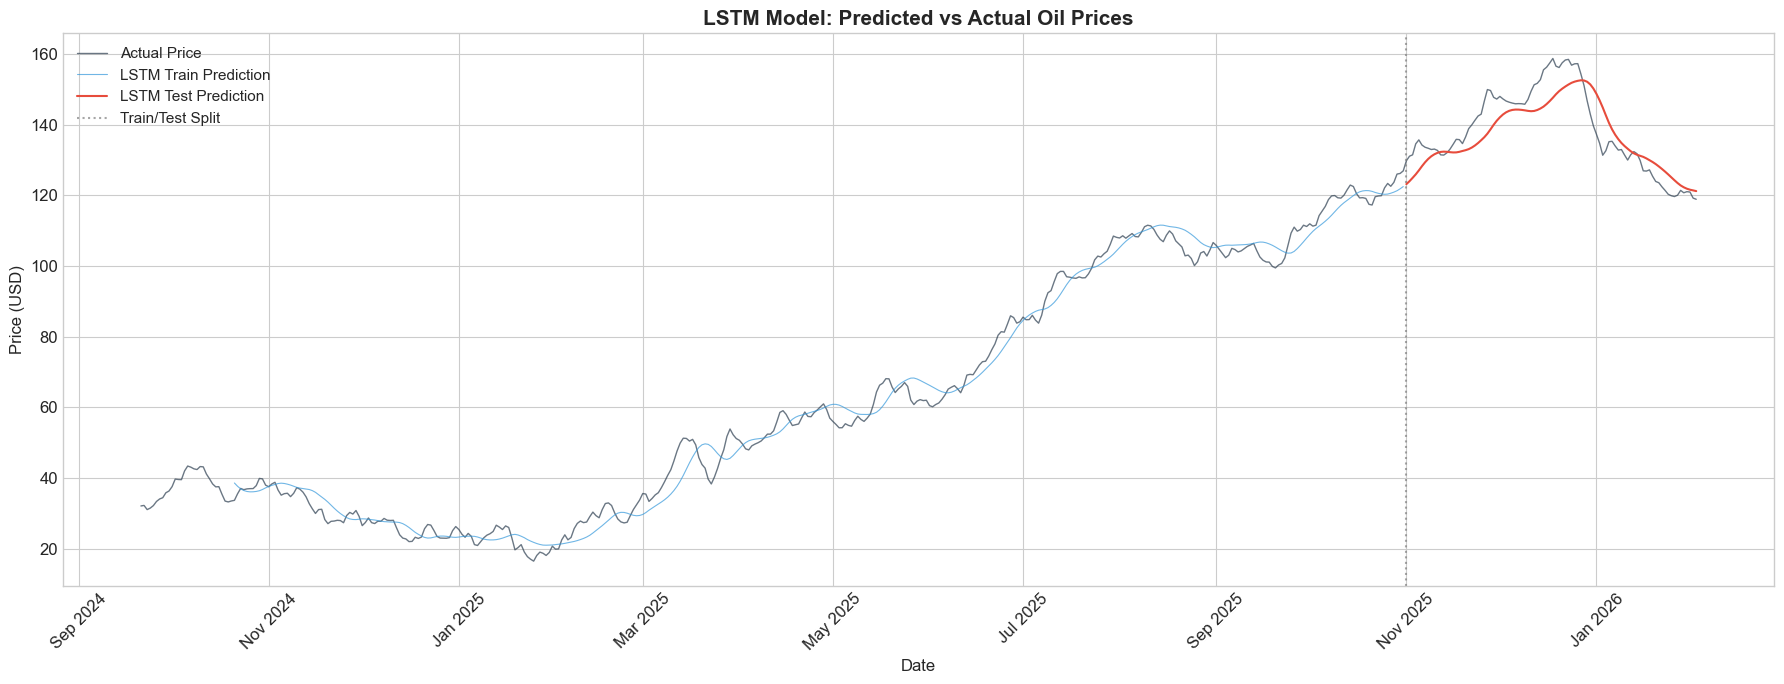

In [16]:
# ============================================================
# Section 13: Evaluate LSTM predictions on the test set
# ============================================================

# Generate predictions
y_pred_scaled = best_model_lstm.predict(X_test)

# Inverse transform to get actual price values
y_pred_actual = scaler.inverse_transform(y_pred_scaled).flatten()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Compute metrics
lstm_metrics = compute_metrics(y_test_actual, y_pred_actual, 'LSTM')

# Create test date index (offset by look_back + split)
test_dates = df.index[LOOK_BACK + split_idx:LOOK_BACK + split_idx + len(y_test)]

# Also get training predictions for full plot
y_train_pred_scaled = best_model_lstm.predict(X_train)
y_train_pred_actual = scaler.inverse_transform(y_train_pred_scaled).flatten()
train_dates = df.index[LOOK_BACK:LOOK_BACK + len(y_train)]

# Plot
fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(df.index, df['price'], label='Actual Price', color='#2c3e50', linewidth=1.0, alpha=0.7)
ax.plot(train_dates, y_train_pred_actual, label='LSTM Train Prediction', 
        color='#3498db', linewidth=0.8, alpha=0.7)
ax.plot(test_dates, y_pred_actual, label='LSTM Test Prediction', 
        color='#e74c3c', linewidth=1.5)
ax.axvline(test_dates[0], color='grey', linestyle=':', alpha=0.7, label='Train/Test Split')
ax.set_title('LSTM Model: Predicted vs Actual Oil Prices', fontweight='bold', fontsize=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig10_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## **14. LSTM 24-Month Forecast with Confidence Intervals**

Generating LSTM 24-month forecast with Monte Carlo Dropout...
(This may take a moment with 100 simulations)


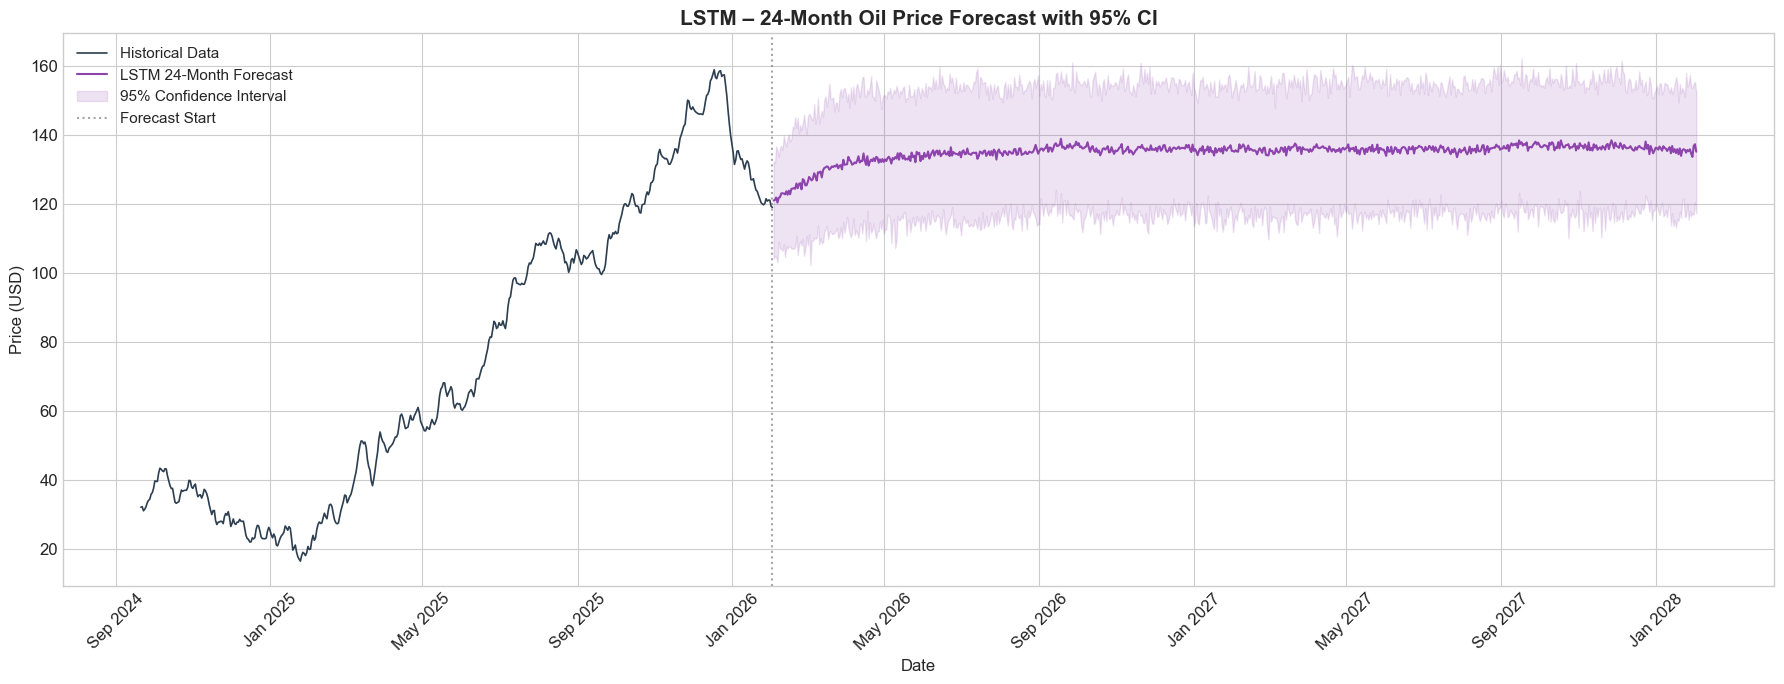


LSTM Forecast Start: $120.93
LSTM Forecast End: $135.08
95% CI at End: [$117.24, $152.22]


In [17]:
# ============================================================
# Section 14: Generate 24-month LSTM forecast using recursive
#             multi-step prediction with Monte Carlo dropout
#             for confidence intervals
# ============================================================

def lstm_forecast_with_ci(model, last_sequence, n_steps, scaler, n_simulations=100):
    """
    Generate multi-step LSTM forecast with confidence intervals
    using Monte Carlo Dropout for uncertainty estimation.
    
    Parameters:
    -----------
    model : keras model with dropout layers
    last_sequence : np.array - last look_back values (scaled)
    n_steps : int - number of steps to forecast
    scaler : MinMaxScaler - fitted scaler for inverse transform
    n_simulations : int - number of Monte Carlo simulations
    
    Returns:
    --------
    mean_forecast, lower_ci, upper_ci : np.arrays of actual price values
    """
    all_forecasts = []
    
    for sim in range(n_simulations):
        current_seq = last_sequence.copy()
        forecast = []
        
        for step in range(n_steps):
            input_seq = current_seq.reshape(1, len(current_seq), 1)
            # Use training=True to enable dropout during inference (MC Dropout)
            pred = model(input_seq, training=True).numpy()[0, 0]
            forecast.append(pred)
            # Shift the window forward
            current_seq = np.append(current_seq[1:], pred)
        
        # Inverse transform
        forecast_actual = scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()
        all_forecasts.append(forecast_actual)
    
    all_forecasts = np.array(all_forecasts)
    mean_forecast = np.mean(all_forecasts, axis=0)
    lower_ci = np.percentile(all_forecasts, 2.5, axis=0)
    upper_ci = np.percentile(all_forecasts, 97.5, axis=0)
    
    return mean_forecast, lower_ci, upper_ci

# Get the last sequence from the scaled data
last_seq = price_scaled[-LOOK_BACK:, 0]

# Forecast 24 months (~730 days)
print('Generating LSTM 24-month forecast with Monte Carlo Dropout...')
print('(This may take a moment with 100 simulations)')

lstm_mean, lstm_lower, lstm_upper = lstm_forecast_with_ci(
    best_model_lstm, last_seq, forecast_steps, scaler, n_simulations=100
)

# Create forecast dates
lstm_forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), 
                                      periods=forecast_steps, freq='D')

# Plot LSTM forecast
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(df.index, df['price'], label='Historical Data', color='#2c3e50', linewidth=1.2)
ax.plot(lstm_forecast_dates, lstm_mean, label='LSTM 24-Month Forecast',
        color='#8e44ad', linewidth=1.5)
ax.fill_between(lstm_forecast_dates, lstm_lower, lstm_upper,
                color='#8e44ad', alpha=0.15, label='95% Confidence Interval')
ax.axvline(last_date, color='grey', linestyle=':', alpha=0.7, label='Forecast Start')
ax.set_title('LSTM – 24-Month Oil Price Forecast with 95% CI', fontweight='bold', fontsize=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig11_lstm_24month_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLSTM Forecast Start: ${lstm_mean[0]:.2f}')
print(f'LSTM Forecast End: ${lstm_mean[-1]:.2f}')
print(f'95% CI at End: [${lstm_lower[-1]:.2f}, ${lstm_upper[-1]:.2f}]')

## **15. Model Comparison: ARIMA vs LSTM**

MODEL COMPARISON: ARIMA vs LSTM
  Metric  ARIMA(2, 2, 7)     LSTM
    RMSE       27.251715 5.971320
     MAE       21.331750 4.982428
MAPE (%)       16.750816 3.546874

(Lower values indicate better performance for all metrics)


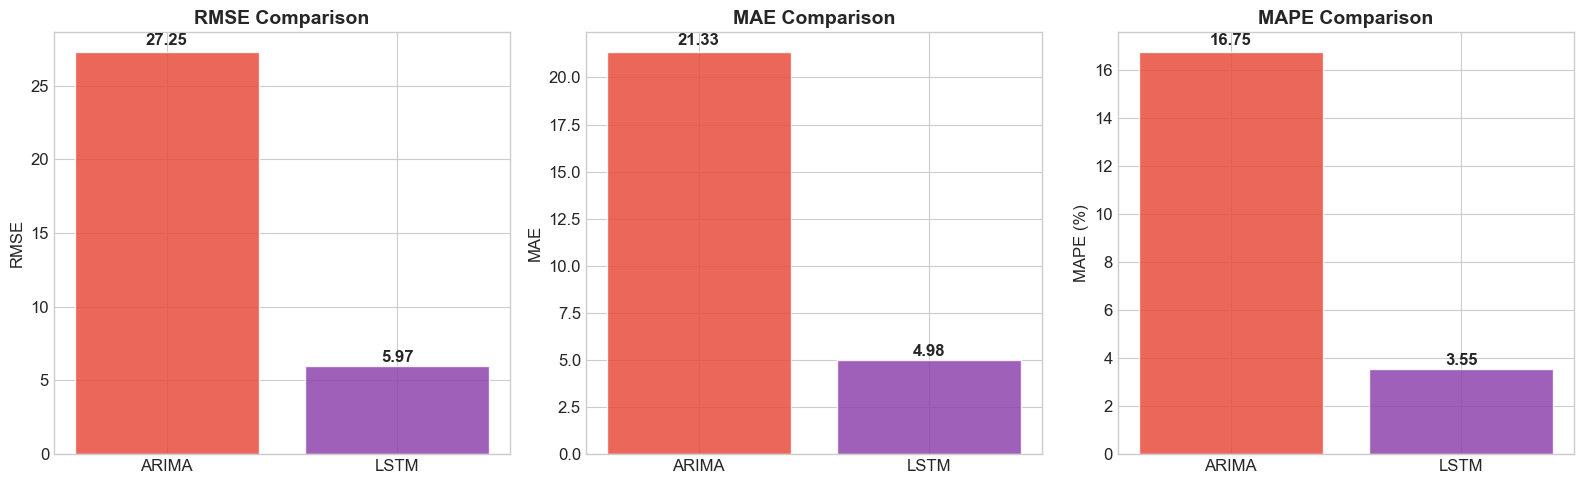

In [18]:
# ============================================================
# Section 15: Compare both models side-by-side
# ============================================================

# Comparison table
comparison = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
    f'ARIMA{best_order}': [arima_metrics['RMSE'], arima_metrics['MAE'], arima_metrics['MAPE']],
    'LSTM': [lstm_metrics['RMSE'], lstm_metrics['MAE'], lstm_metrics['MAPE']]
})

print('=' * 55)
print('MODEL COMPARISON: ARIMA vs LSTM')
print('=' * 55)
print(comparison.to_string(index=False))
print('\n(Lower values indicate better performance for all metrics)')

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_names = ['RMSE', 'MAE', 'MAPE']
arima_vals = [arima_metrics['RMSE'], arima_metrics['MAE'], arima_metrics['MAPE']]
lstm_vals = [lstm_metrics['RMSE'], lstm_metrics['MAE'], lstm_metrics['MAPE']]

for i, (metric, arima_v, lstm_v) in enumerate(zip(metrics_names, arima_vals, lstm_vals)):
    bars = axes[i].bar(['ARIMA', 'LSTM'], [arima_v, lstm_v], 
                       color=['#e74c3c', '#8e44ad'], alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric + (' (%)' if metric == 'MAPE' else ''))
    for bar, val in zip(bars, [arima_v, lstm_v]):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01*bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

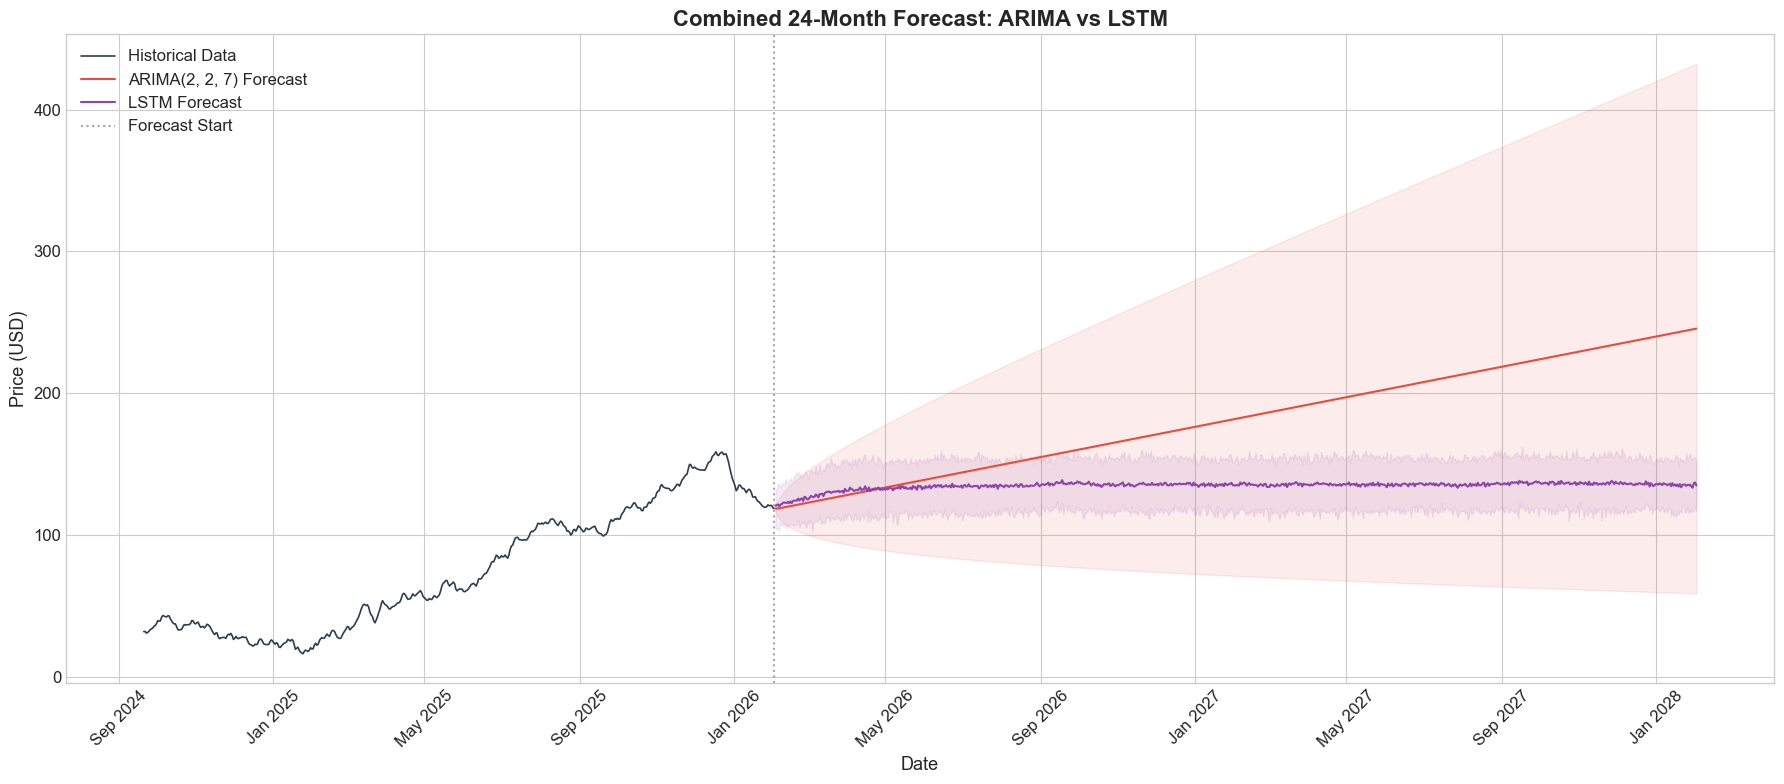

Combined forecast figure saved successfully.


In [19]:
# ============================================================
# Section 15b: Combined forecast plot
# ============================================================

fig, ax = plt.subplots(figsize=(18, 8))

# Historical data
ax.plot(df.index, df['price'], label='Historical Data', color='#2c3e50', linewidth=1.2)

# ARIMA forecast
ax.plot(forecast_dates, forecast_mean, label=f'ARIMA{best_order} Forecast',
        color='#e74c3c', linewidth=1.5, linestyle='-')
ax.fill_between(forecast_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color='#e74c3c', alpha=0.1)

# LSTM forecast
ax.plot(lstm_forecast_dates, lstm_mean, label='LSTM Forecast',
        color='#8e44ad', linewidth=1.5, linestyle='-')
ax.fill_between(lstm_forecast_dates, lstm_lower, lstm_upper,
                color='#8e44ad', alpha=0.1)

ax.axvline(last_date, color='grey', linestyle=':', alpha=0.7, label='Forecast Start')
ax.set_title('Combined 24-Month Forecast: ARIMA vs LSTM', fontweight='bold', fontsize=16)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Price (USD)', fontsize=13)
ax.legend(loc='upper left', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig13_combined_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('Combined forecast figure saved successfully.')

## **16. Summary and Key Findings**

### **Key Observations:**

1. **Data Characteristics:** The oil price series (Sep 2024 – Feb 2026) exhibits a strong upward trend from ~$32 to ~$158, followed by a decline. The series is clearly non-stationary with changing mean and variance.

2. **Stationarity:** The ADF and KPSS tests confirmed non-stationarity in the original series. First-order differencing (d=1) was sufficient to achieve stationarity.

3. **ARIMA Modelling:** An exhaustive grid search over p=[0,8], d=[0,2], q=[0,8] identified the optimal model based on minimising the AIC criterion. The residual diagnostics (ACF, distribution, Q-Q plot) provide insight into model adequacy.

4. **LSTM Modelling:** A stacked two-layer LSTM with dropout regularisation was trained. Hyperparameter tuning tested multiple configurations. Monte Carlo Dropout was used to generate probabilistic confidence intervals.

5. **Comparison:** Both models were evaluated using RMSE, MAE, and MAPE. The comparison highlights the strengths and weaknesses of linear vs non-linear approaches for this particular dataset.

6. **Forecast Uncertainty:** The widening confidence intervals in both models reflect increasing uncertainty over longer forecast horizons, which is expected in financial time series.

### **Future Work:**
- Incorporate exogenous variables (geopolitical indices, supply/demand data) via ARIMAX or multivariate LSTM
- Explore hybrid models combining ARIMA and LSTM (Zhang, 2003)
- Apply Transformer-based architectures for time series (e.g., Temporal Fusion Transformers)
- Implement ensemble approaches to reduce forecast variance
- Use GARCH models to capture volatility clustering observed in the returns

In [20]:
# ============================================================
# Section 16: Final summary statistics
# ============================================================

print('=' * 60)
print('FINAL ANALYSIS SUMMARY')
print('=' * 60)
print(f'\nDataset: Daily Oil Prices')
print(f'Period: {df.index.min().strftime("%d %b %Y")} to {df.index.max().strftime("%d %b %Y")}')
print(f'Observations: {len(df)}')
print(f'Price Range: ${df["price"].min():.2f} - ${df["price"].max():.2f}')
print(f'\n--- ARIMA ---')
print(f'Best Model: ARIMA{best_order}')
print(f'AIC: {results_df.iloc[0]["AIC"]:.2f}')
print(f'Test RMSE: {arima_metrics["RMSE"]:.4f}')
print(f'Test MAE: {arima_metrics["MAE"]:.4f}')
print(f'Test MAPE: {arima_metrics["MAPE"]:.2f}%')
print(f'\n--- LSTM ---')
print(f'Architecture: {best_config["units_1"]}-{best_config["units_2"]} units, '
      f'dropout={best_config["dropout"]}, look_back={LOOK_BACK}')
print(f'Test RMSE: {lstm_metrics["RMSE"]:.4f}')
print(f'Test MAE: {lstm_metrics["MAE"]:.4f}')
print(f'Test MAPE: {lstm_metrics["MAPE"]:.2f}%')
print(f'\nForecast Horizon: 24 months ({forecast_steps} days)')
print(f'\nAnalysis complete. All figures saved.')

FINAL ANALYSIS SUMMARY

Dataset: Daily Oil Prices
Period: 21 Sep 2024 to 02 Feb 2026
Observations: 500
Price Range: $16.48 - $158.78

--- ARIMA ---
Best Model: ARIMA(2, 2, 7)
AIC: 1429.22
Test RMSE: 27.2517
Test MAE: 21.3318
Test MAPE: 16.75%

--- LSTM ---
Architecture: 128-64 units, dropout=0.2, look_back=30
Test RMSE: 5.9713
Test MAE: 4.9824
Test MAPE: 3.55%

Forecast Horizon: 24 months (730 days)

Analysis complete. All figures saved.
